# Demo 4 — Detect objects

_Section 4: Object Detection._

Detection answers: **"What objects are here, and where?"** Instead of one label for the whole image, we get a **box + label + confidence** for each object. We'll run a detector (**RF-DETR**) on the scene and watch labelled boxes appear.

In [1]:
import warnings

import cv2
import matplotlib.pyplot as plt
from PIL import Image
import supervision as sv
from rfdetr import RFDETRSmall
from rfdetr.assets.coco_classes import COCO_CLASSES

warnings.filterwarnings("ignore")

IMG_PATH = "demo.jpg"  # the shared image used across all demos

objc[71037]: Class AVFFrameReceiver is implemented in both /Users/mahyoubm/Documents/adhoc/cv-intro/.venv/lib/python3.12/site-packages/cv2/.dylibs/libavdevice.61.3.100.dylib (0x10c6a43a8) and /Users/mahyoubm/Documents/adhoc/cv-intro/.venv/lib/python3.12/site-packages/av/.dylibs/libavdevice.62.3.102.dylib (0x1222943a8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[71037]: Class AVFAudioReceiver is implemented in both /Users/mahyoubm/Documents/adhoc/cv-intro/.venv/lib/python3.12/site-packages/cv2/.dylibs/libavdevice.61.3.100.dylib (0x10c6a43f8) and /Users/mahyoubm/Documents/adhoc/cv-intro/.venv/lib/python3.12/site-packages/av/.dylibs/libavdevice.62.3.102.dylib (0x1222943f8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
/Users/mahyoubm/Documents/adhoc/cv-intro/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. P

## 1. Load the image and the detector

We read the image with OpenCV (BGR → RGB). **RF-DETR** is a modern detector trained on **COCO** (80 everyday object classes). It looks at the whole image **once** and directly outputs a list of boxes.

In [2]:
bgr = cv2.imread(IMG_PATH)                    # OpenCV loads as BGR
rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)    # -> RGB
image = Image.fromarray(rgb)                  # RF-DETR takes a PIL image

model = RFDETRSmall()
print("Loaded RF-DETR (small) — trained on 80 COCO object classes.")

[2026-08-15 23:59:04] [INFO] rf-detr - File /Users/mahyoubm/.roboflow/models/rf-detr-small.pth already exists with correct MD5 hash.


[2026-08-15 23:59:04] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-08-15 23:59:04] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-08-15 23:59:05] [INFO] rf-detr - File /Users/mahyoubm/.roboflow/models/rf-detr-small.pth already exists with correct MD5 hash.
Loaded RF-DETR (small) — trained on 80 COCO object classes.


## 2. Run the detector

`predict` returns a set of detections: for each object a **box** (x, y, x, y), a **class**, and a **confidence** score. `threshold` keeps only boxes the model is at least this sure about.

In [3]:
detections = model.predict(image, threshold=0.5)

print(f"Found {len(detections)} objects:\n")
for (x1, y1, x2, y2), cls, conf in zip(
    detections.xyxy, detections.class_id, detections.confidence
):
    name = COCO_CLASSES[cls]
    print(f"  {name:12s} {conf*100:5.1f}%   box=({x1:.0f}, {y1:.0f}, {x2:.0f}, {y2:.0f})")

[2026-08-15 23:59:06] [WARNING] rf-detr - Model is not optimized for inference. Latency may be higher than expected. For full GPU throughput (e.g. ~8x on T4 via FP16 Tensor Cores), call model.inference(dtype=torch.float16).


Found 5 objects:

  person        94.2%   box=(55, 73, 228, 294)
  sports ball   93.4%   box=(196, 244, 257, 304)
  cat           92.9%   box=(222, 120, 480, 304)
  couch         92.4%   box=(208, 45, 480, 201)
  chair         72.8%   box=(0, 45, 73, 209)


## 3. Draw the boxes

We use **supervision** to paint each box and label onto the image.

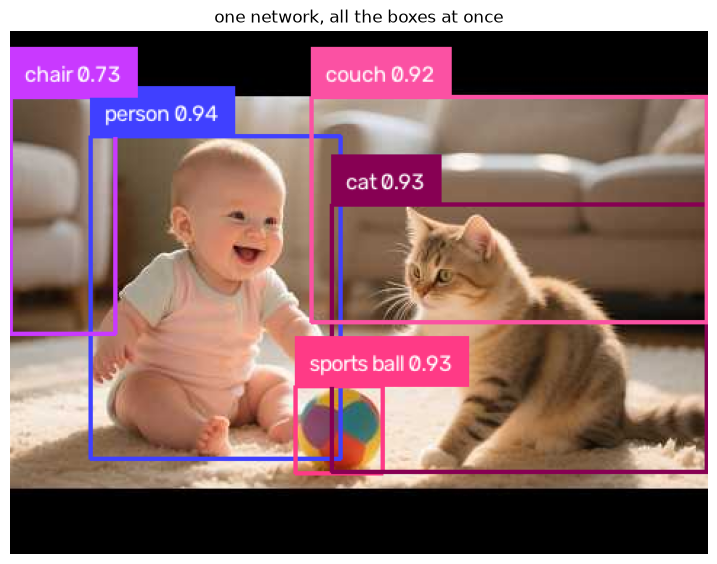

In [4]:
box_annotator = sv.BoxAnnotator()
label_annotator = sv.LabelAnnotator()


def annotate(scene_rgb, detections):
    """Draw labelled boxes onto a copy of the RGB image."""
    labels = [
        f"{COCO_CLASSES[c]} {conf:.2f}"
        for c, conf in zip(detections.class_id, detections.confidence)
    ]
    out = scene_rgb.copy()
    out = box_annotator.annotate(out, detections)
    out = label_annotator.annotate(out, detections, labels)
    return out


annotated = annotate(rgb, detections)

plt.figure(figsize=(9, 7))
plt.imshow(annotated)
plt.axis("off")
plt.title("one network, all the boxes at once")
plt.show()

Compare this to Demo 3: classification could only say *"soccer ball"* for the whole picture. Detection finds the **baby (person), cat, ball, couch, and chair** — each with its own box.

## 4. The confidence threshold

Every box comes with a score. Lower the threshold and the model reports more (shakier) guesses; raise it and only the confident ones survive.

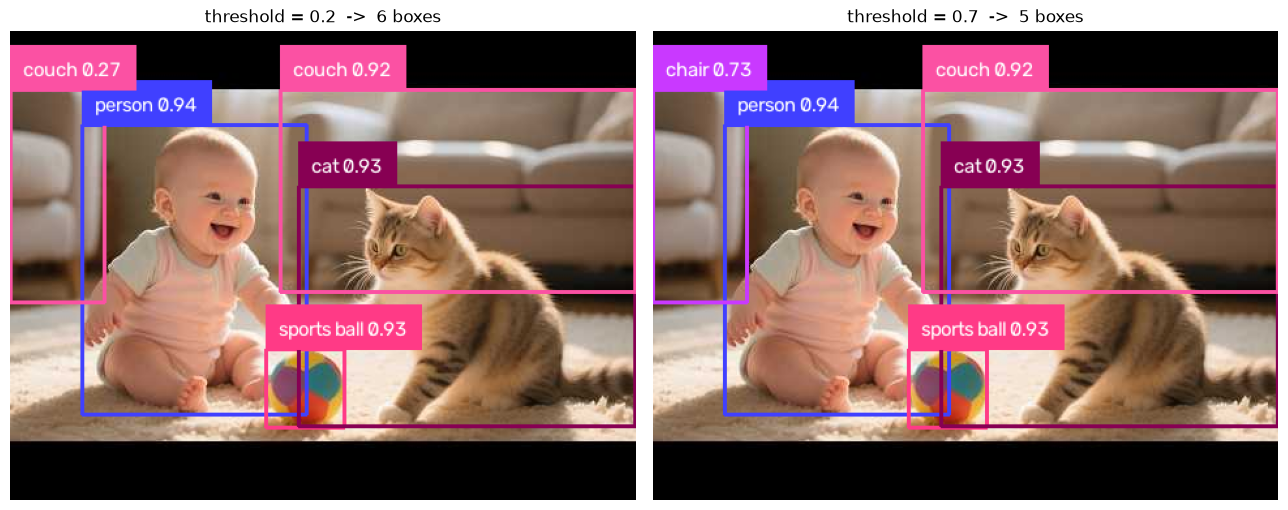

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, thr in zip(axes, [0.2, 0.7]):
    dets = model.predict(image, threshold=thr)
    ax.imshow(annotate(rgb, dets))
    ax.axis("off")
    ax.set_title(f"threshold = {thr}  ->  {len(dets)} boxes")
plt.tight_layout()
plt.show()

## Takeaway

Detection tells us **what** and roughly **where** — but a box is a blunt rectangle that includes background corners. It doesn't capture an object's exact shape.

To label **which exact pixels** belong to each object, we need the next task: **segmentation**.